In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("✅ Imports OK")

✅ Imports OK


In [ ]:
uploaded = files.upload()

df = pd.read_csv("aqua_atmos_dataset.csv")
print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Saving aqua_atmos_dataset.csv to aqua_atmos_dataset.csv
✅ Dataset chargé : 11088 lignes, 17 colonnes


In [ ]:
print("=" * 60)
print("APERÇU DES PREMIÈRES LIGNES")
print("=" * 60)
display(df.head(10))

print("\n" + "=" * 60)
print("TYPES DE COLONNES")
print("=" * 60)
print(df.dtypes)

APERÇU DES PREMIÈRES LIGNES


,scenario,jour,heure,X1_temp_ambiante,X2_humidite,X3_temp_condensation,X4_temp_CaCl2,X5_saturation_CaCl2,X6_puissance_solaire,X7_batterie,X8_reservoir,X9_conso_vcrc,X10_mois,Y1_production,Y2_activation,Y3_anomalie,Y4_duree
0,Modere_Humide,6,10.17,20.94,92.11,15.21,15.15,40.07,137.61,67.35,26.45,151.42,6,0.634000,1,0,32.2
1,Modere_Sec,3,8.00,16.83,58.94,3.04,14.00,16.61,75.41,84.56,13.64,132.97,3,0.413000,1,0,39.5
2,Modere_Humide,6,3.83,22.52,78.92,11.45,20.49,35.63,0.00,73.52,21.60,147.65,6,0.912000,1,0,27.0
3,Chaud_Humide,3,5.00,31.83,99.05,26.46,28.76,33.03,0.00,73.63,16.97,164.23,3,1.449000,1,0,24.3
4,Modere,10,18.17,26.33,36.72,7.40,23.49,30.31,0.00,82.26,22.83,167.55,10,0.257000,0,0,0.0
5,Chaud_Humide,5,12.50,32.73,98.21,26.70,28.90,41.78,144.81,51.83,41.48,149.00,5,1.636000,1,0,27.5
6,Modere_Humide,1,9.00,20.21,89.76,13.73,17.70,39.14,102.88,64.57,22.17,152.82,1,0.635000,1,0,28.9
7,Froid_Humide,5,14.17,17.40,79.03,7.28,13.09,41.08,130.83,75.96,25.38,132.19,5,0.619000,1,0,39.9
8,Modere_Humide,1,9.33,19.46,89.37,11.49,17.53,39.38,114.72,64.45,22.44,140.47,1,0.756000,1,0,32.1
9,Modere_Sec,10,19.17,25.73,28.78,2.33,23.91,19.73,0.00,82.24,15.42,159.34,10,0.073393,0,0,0.0



TYPES DE COLONNES
scenario                 object
jour                      int64
heure                   float64
X1_temp_ambiante        float64
X2_humidite             float64
X3_temp_condensation    float64
X4_temp_CaCl2           float64
X5_saturation_CaCl2     float64
X6_puissance_solaire    float64
X7_batterie             float64
X8_reservoir            float64
X9_conso_vcrc           float64
X10_mois                  int64
Y1_production           float64
Y2_activation             int64
Y3_anomalie               int64
Y4_duree                float64
dtype: object


In [ ]:
print("=" * 60)
print("QUALITÉ DES DONNÉES")
print("=" * 60)

print(f"\n📌 Valeurs manquantes :")
print(df.isnull().sum())

print(f"\n📌 Doublons : {df.duplicated().sum()}")

print(f"\n📌 Distribution des scénarios :")
print(df['scenario'].value_counts())

print(f"\n📌 Distribution Y3 (anomalies) :")
print(df['Y3_anomalie'].value_counts())
print(f"   Ratio anomalies : {df['Y3_anomalie'].mean()*100:.1f}%")

print(f"\n📌 Distribution Y2 (activation VCRC) :")
print(df['Y2_activation'].value_counts())
print(f"   Ratio activation : {df['Y2_activation'].mean()*100:.1f}%")

QUALITÉ DES DONNÉES

📌 Valeurs manquantes :
scenario                0
jour                    0
heure                   0
X1_temp_ambiante        0
X2_humidite             0
X3_temp_condensation    0
X4_temp_CaCl2           0
X5_saturation_CaCl2     0
X6_puissance_solaire    0
X7_batterie             0
X8_reservoir            0
X9_conso_vcrc           0
X10_mois                0
Y1_production           0
Y2_activation           0
Y3_anomalie             0
Y4_duree                0
dtype: int64

📌 Doublons : 0

📌 Distribution des scénarios :
scenario
Modere                 1591
Chaud_Sec              1590
Chaud_Humide           1590
Chaud_Modere_Humide    1582
Froid_Humide           1581
Modere_Sec             1579
Modere_Humide          1575
Name: count, dtype: int64

📌 Distribution Y3 (anomalies) :
Y3_anomalie
0    10080
1     1008
Name: count, dtype: int64
   Ratio anomalies : 9.1%

📌 Distribution Y2 (activation VCRC) :
Y2_activation
1    7075
0    4013
Name: count, dtype: int64
   R

In [ ]:
X_cols = ['X1_temp_ambiante', 'X2_humidite', 'X3_temp_condensation',
          'X4_temp_CaCl2', 'X5_saturation_CaCl2', 'X6_puissance_solaire',
          'X7_batterie', 'X8_reservoir', 'X9_conso_vcrc']

print("=" * 60)
print("STATISTIQUES DESCRIPTIVES — VARIABLES X")
print("=" * 60)
display(df[X_cols].describe().round(2))

Y_cols = ['Y1_production', 'Y2_activation', 'Y3_anomalie', 'Y4_duree']
print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES — VARIABLES Y")
print("=" * 60)
display(df[Y_cols].describe().round(2))

STATISTIQUES DESCRIPTIVES — VARIABLES X


,X1_temp_ambiante,X2_humidite,X3_temp_condensation,X4_temp_CaCl2,X5_saturation_CaCl2,X6_puissance_solaire,X7_batterie,X8_reservoir,X9_conso_vcrc
count,11088.00,11088.00,11088.00,11088.00,11088.00,11088.00,11088.00,11088.00,11088.00
mean,28.11,62.69,13.46,24.08,33.49,47.69,64.35,24.60,151.63
std,8.55,23.53,9.01,8.68,10.90,57.85,14.22,10.96,16.29
min,15.00,11.71,0.02,10.00,12.35,0.00,25.43,6.21,130.00
25%,20.69,42.15,5.50,16.71,26.14,0.00,54.06,15.61,140.25
50%,26.98,64.02,11.79,23.24,32.67,0.00,64.91,24.06,150.44
75%,35.77,82.65,22.05,31.72,40.29,105.77,75.17,31.16,160.39
max,47.82,100.00,45.27,42.81,100.00,157.68,100.00,61.92,266.88



STATISTIQUES DESCRIPTIVES — VARIABLES Y


,Y1_production,Y2_activation,Y3_anomalie,Y4_duree
count,11088.00,11088.00,11088.00,11088.00
mean,0.77,0.64,0.09,16.35
std,0.55,0.48,0.29,13.34
min,0.01,0.00,0.00,0.00
25%,0.40,0.00,0.00,0.00
50%,0.62,1.00,0.00,20.35
75%,1.03,1.00,0.00,27.60
max,3.34,1.00,1.00,44.20


In [ ]:
print("=" * 60)
print("PRODUCTION MOYENNE PAR SCÉNARIO")
print("=" * 60)

scenario_stats = df.groupby('scenario').agg(
    Y1_moyen=('Y1_production', 'mean'),
    Y1_max=('Y1_production', 'max'),
    Y2_actif_pct=('Y2_activation', lambda x: f"{x.mean()*100:.1f}%"),
    nb_lignes=('Y1_production', 'count')
)

display(scenario_stats)

PRODUCTION MOYENNE PAR SCÉNARIO


,Y1_moyen,Y1_max,Y2_actif_pct,nb_lignes
scenario,,,,
Chaud_Humide,1.628900,3.345,92.6%,1590
Chaud_Modere_Humide,1.221067,2.424,89.9%,1582
Chaud_Sec,0.381388,1.292,0.0%,1590
Froid_Humide,0.587436,1.024,100.0%,1581
Modere,0.435194,0.693,38.8%,1591
Modere_Humide,0.764756,1.408,100.0%,1575
Modere_Sec,0.382973,0.693,25.8%,1579


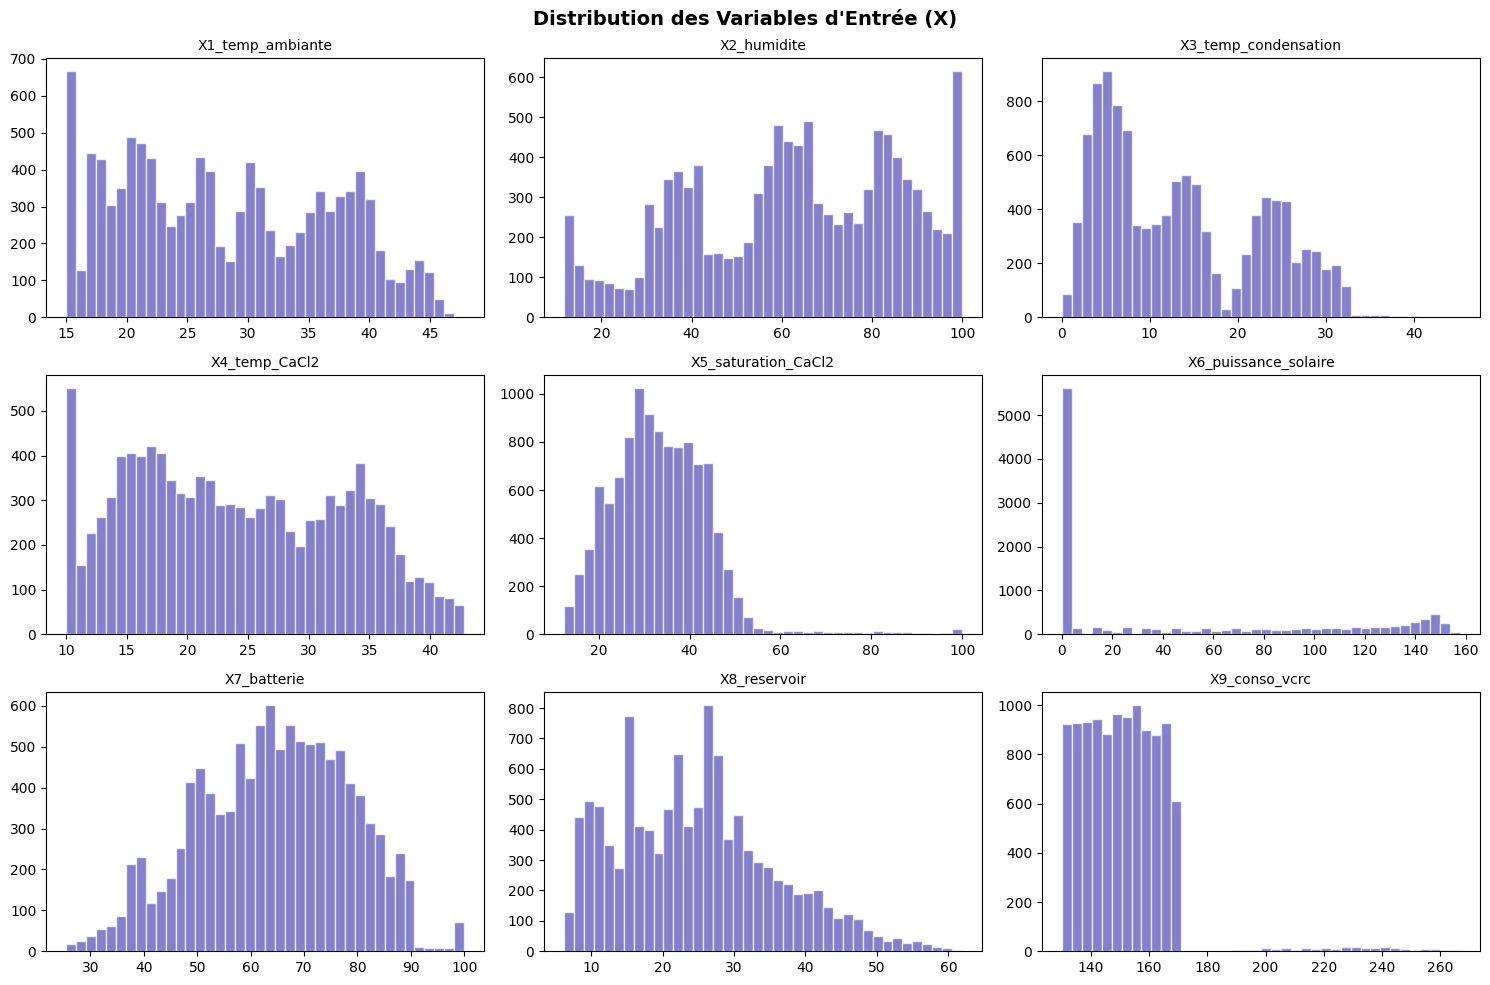

✅ Figure sauvegardée


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Distribution des Variables d'Entrée (X)", fontsize=14, fontweight='bold')

for i, col in enumerate(X_cols):
    ax = axes[i//3, i%3]
    df[col].hist(bins=40, ax=ax, color='#534AB7', alpha=0.7, edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.grid(False)

plt.tight_layout()
plt.savefig('distributions_X.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")

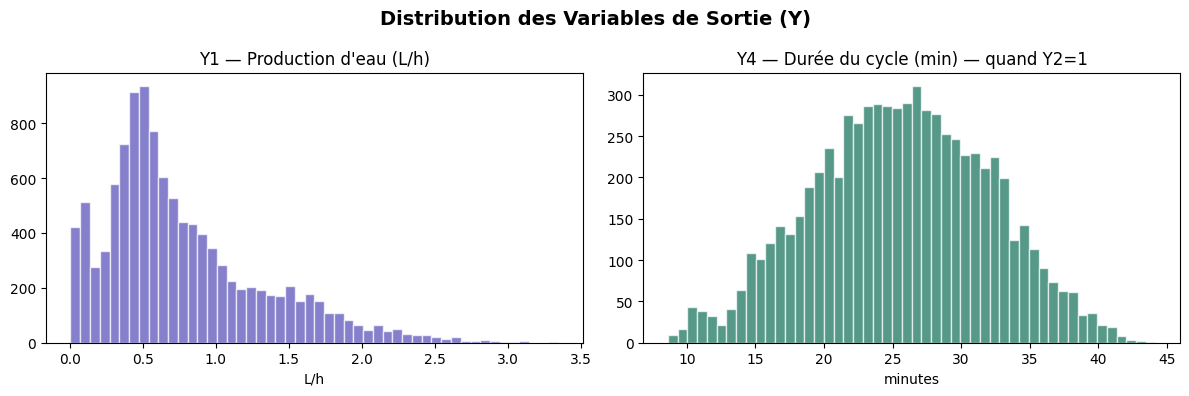

✅ Figure sauvegardée


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution des Variables de Sortie (Y)", fontsize=14, fontweight='bold')

df['Y1_production'].hist(bins=50, ax=axes[0], color='#534AB7', alpha=0.7, edgecolor='white')
axes[0].set_title("Y1 — Production d'eau (L/h)")
axes[0].set_xlabel('L/h')
axes[0].grid(False)

df[df['Y4_duree'] > 0]['Y4_duree'].hist(bins=50, ax=axes[1], color='#0F6E56', alpha=0.7, edgecolor='white')
axes[1].set_title("Y4 — Durée du cycle (min) — quand Y2=1")
axes[1].set_xlabel('minutes')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('distributions_Y.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")

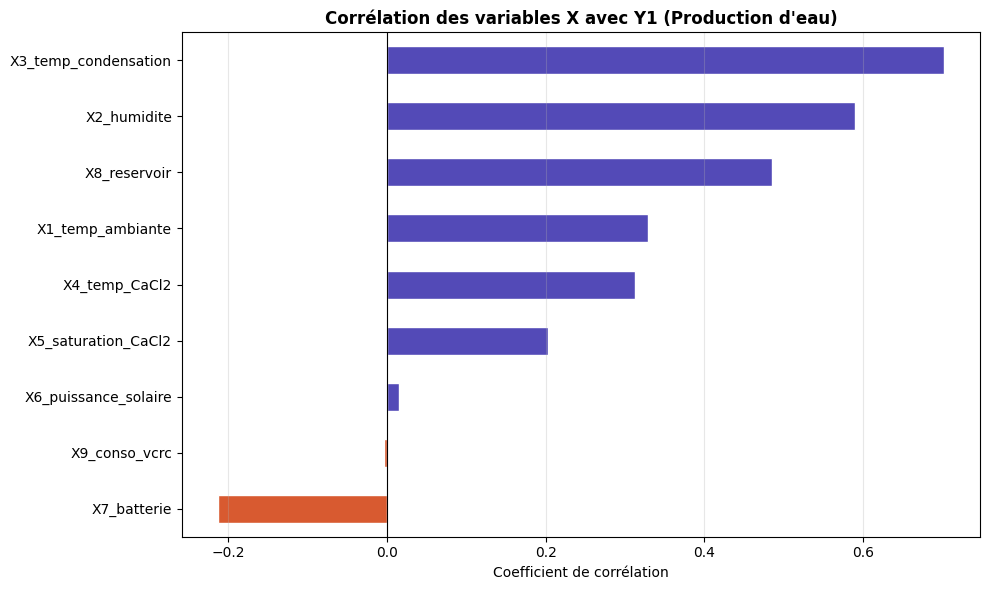

✅ Figure sauvegardée


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

corr = df[X_cols + ['Y1_production']].corr()['Y1_production'].drop('Y1_production').sort_values()
colors = ['#D85A30' if v < 0 else '#534AB7' for v in corr]

corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("Corrélation des variables X avec Y1 (Production d'eau)", fontweight='bold')
ax.set_xlabel('Coefficient de corrélation')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_Y1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")

In [ ]:
print("=" * 60)
print("NETTOYAGE FINAL")
print("=" * 60)

cols_to_drop = [c for c in ['scenario', 'jour', 'heure'] if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

print(f"✅ Colonnes supprimées : {cols_to_drop}")
print(f"✅ Dataset propre : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
print(f"\nColonnes restantes :")
print(list(df_clean.columns))

assert df_clean.isnull().sum().sum() == 0, "❌ Valeurs manquantes détectées"
print(f"\n✅ Aucune valeur manquante")
print(f"✅ Dataset prêt pour l'entraînement")

display(df_clean.head(5))

NETTOYAGE FINAL
✅ Colonnes supprimées : ['scenario', 'jour', 'heure']
✅ Dataset propre : 11088 lignes × 14 colonnes

Colonnes restantes :
['X1_temp_ambiante', 'X2_humidite', 'X3_temp_condensation', 'X4_temp_CaCl2', 'X5_saturation_CaCl2', 'X6_puissance_solaire', 'X7_batterie', 'X8_reservoir', 'X9_conso_vcrc', 'X10_mois', 'Y1_production', 'Y2_activation', 'Y3_anomalie', 'Y4_duree']

✅ Aucune valeur manquante
✅ Dataset prêt pour l'entraînement


,X1_temp_ambiante,X2_humidite,X3_temp_condensation,X4_temp_CaCl2,X5_saturation_CaCl2,X6_puissance_solaire,X7_batterie,X8_reservoir,X9_conso_vcrc,X10_mois,Y1_production,Y2_activation,Y3_anomalie,Y4_duree
0,20.94,92.11,15.21,15.15,40.07,137.61,67.35,26.45,151.42,6,0.634,1,0,32.2
1,16.83,58.94,3.04,14.00,16.61,75.41,84.56,13.64,132.97,3,0.413,1,0,39.5
2,22.52,78.92,11.45,20.49,35.63,0.00,73.52,21.60,147.65,6,0.912,1,0,27.0
3,31.83,99.05,26.46,28.76,33.03,0.00,73.63,16.97,164.23,3,1.449,1,0,24.3
4,26.33,36.72,7.40,23.49,30.31,0.00,82.26,22.83,167.55,10,0.257,0,0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

# Variables X et Y
X = df_clean[['X1_temp_ambiante', 'X2_humidite', 'X3_temp_condensation',
              'X4_temp_CaCl2', 'X5_saturation_CaCl2', 'X6_puissance_solaire',
              'X7_batterie', 'X8_reservoir', 'X9_conso_vcrc', 'X10_mois']]

Y1 = df_clean['Y1_production']
Y2 = df_clean['Y2_activation']
Y3 = df_clean['Y3_anomalie']
Y4 = df_clean['Y4_duree']

# Split 70% train / 15% validation / 15% test
X_train, X_temp, Y1_train, Y1_temp = train_test_split(X, Y1, test_size=0.30, random_state=42)
X_val, X_test, Y1_val, Y1_test = train_test_split(X_temp, Y1_temp, test_size=0.50, random_state=42)

# Même split pour Y2 Y3 Y4
_, _, Y2_train, Y2_temp = train_test_split(X, Y2, test_size=0.30, random_state=42)
Y2_val, Y2_test = train_test_split(Y2_temp, test_size=0.50, random_state=42)

_, _, Y3_train, Y3_temp = train_test_split(X, Y3, test_size=0.30, random_state=42)
Y3_val, Y3_test = train_test_split(Y3_temp, test_size=0.50, random_state=42)

_, _, Y4_train, Y4_temp = train_test_split(X, Y4, test_size=0.30, random_state=42)
Y4_val, Y4_test = train_test_split(Y4_temp, test_size=0.50, random_state=42)

print(f"✅ Train      : {len(X_train)} lignes ({len(X_train)/len(X)*100:.0f}%)")
print(f"✅ Validation : {len(X_val)} lignes ({len(X_val)/len(X)*100:.0f}%)")
print(f"✅ Test       : {len(X_test)} lignes ({len(X_test)/len(X)*100:.0f}%)")

✅ Train      : 7761 lignes (70%)
✅ Validation : 1663 lignes (15%)
✅ Test       : 1664 lignes (15%)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("✅ Normalisation appliquée")
print(f"   Moyenne avant : {X_train.mean().round(2).values}")
print(f"   Moyenne après : {X_train_scaled.mean(axis=0).round(2)}")

✅ Normalisation appliquée
   Moyenne avant : [ 28.11  62.66  13.42  24.07  33.55  48.17  64.45  24.52 151.58   5.48]
   Moyenne après : [ 0. -0. -0.  0. -0.  0. -0.  0. -0.  0.]


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Entraînement
rf_y1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_y1.fit(X_train_scaled, Y1_train)

# Évaluation sur validation
Y1_pred_val = rf_y1.predict(X_val_scaled)
rmse_val = np.sqrt(mean_squared_error(Y1_val, Y1_pred_val))
r2_val   = r2_score(Y1_val, Y1_pred_val)

# Évaluation sur test
Y1_pred_test = rf_y1.predict(X_test_scaled)
rmse_test = np.sqrt(mean_squared_error(Y1_test, Y1_pred_test))
r2_test   = r2_score(Y1_test, Y1_pred_test)

print("=" * 60)
print("RANDOM FOREST — Y1 Production d'eau (L/h)")
print("=" * 60)
print(f"   RMSE Validation : {rmse_val:.4f} L/h")
print(f"   R²   Validation : {r2_val:.4f}")
print(f"   RMSE Test       : {rmse_test:.4f} L/h")
print(f"   R²   Test       : {r2_test:.4f}")

# Baseline — règle simple (moyenne de Y1 train)
baseline_pred = np.full(len(Y1_test), Y1_train.mean())
rmse_baseline = np.sqrt(mean_squared_error(Y1_test, baseline_pred))
print(f"\n   RMSE Baseline   : {rmse_baseline:.4f} L/h")
print(f"   Amélioration vs baseline : {((rmse_baseline - rmse_test)/rmse_baseline)*100:.1f}%")

RANDOM FOREST — Y1 Production d'eau (L/h)
   RMSE Validation : 0.1426 L/h
   R²   Validation : 0.9288
   RMSE Test       : 0.1652 L/h
   R²   Test       : 0.9107

   RMSE Baseline   : 0.5530 L/h
   Amélioration vs baseline : 70.1%


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_y2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_y2.fit(X_train_scaled, Y2_train)

Y2_pred_val  = rf_y2.predict(X_val_scaled)
Y2_pred_test = rf_y2.predict(X_test_scaled)

acc_val  = accuracy_score(Y2_val, Y2_pred_val)
acc_test = accuracy_score(Y2_test, Y2_pred_test)

# Baseline — toujours prédire la classe majoritaire
baseline_class = Y2_train.mode()[0]
baseline_acc   = accuracy_score(Y2_test, [baseline_class]*len(Y2_test))

print("=" * 60)
print("RANDOM FOREST — Y2 Activation VCRC (0/1)")
print("=" * 60)
print(f"   Accuracy Validation : {acc_val*100:.2f}%")
print(f"   Accuracy Test       : {acc_test*100:.2f}%")
print(f"   Accuracy Baseline   : {baseline_acc*100:.2f}%")
print(f"   Amélioration vs baseline : {((acc_test - baseline_acc)/baseline_acc)*100:.1f}%")
print(f"\n{classification_report(Y2_test, Y2_pred_test, target_names=['Attendre', 'Activer'])}")

RANDOM FOREST — Y2 Activation VCRC (0/1)
   Accuracy Validation : 100.00%
   Accuracy Test       : 100.00%
   Accuracy Baseline   : 64.78%
   Amélioration vs baseline : 54.4%

              precision    recall  f1-score   support

    Attendre       1.00      1.00      1.00       586
     Activer       1.00      1.00      1.00      1078

    accuracy                           1.00      1664
   macro avg       1.00      1.00      1.00      1664
weighted avg       1.00      1.00      1.00      1664



In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Entraînement uniquement sur données normales
X_train_normal = X_train_scaled[Y3_train.values == 0]
print(f"Entraînement sur {len(X_train_normal)} lignes normales uniquement")

iso_forest = IsolationForest(contamination=0.10, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_normal)

# Prédiction — Isolation Forest retourne -1 (anomalie) ou 1 (normal)
Y3_pred_raw  = iso_forest.predict(X_test_scaled)
Y3_pred_test = (Y3_pred_raw == -1).astype(int)  # convertir en 0/1

acc_test = accuracy_score(Y3_test, Y3_pred_test)

print("=" * 60)
print("ISOLATION FOREST — Y3 Détection Anomalies (0/1)")
print("=" * 60)
print(f"   Accuracy Test : {acc_test*100:.2f}%")
print(f"\n{classification_report(Y3_test, Y3_pred_test, target_names=['Normal', 'Anomalie'])}")

# Matrice de confusion
cm = confusion_matrix(Y3_test, Y3_pred_test)
print(f"   Matrice de confusion :")
print(f"   [[TN={cm[0,0]}  FP={cm[0,1]}]")
print(f"    [FN={cm[1,0]}  TP={cm[1,1]}]]")

Entraînement sur 7063 lignes normales uniquement
ISOLATION FOREST — Y3 Détection Anomalies (0/1)
   Accuracy Test : 84.31%

              precision    recall  f1-score   support

      Normal       0.92      0.91      0.91      1505
    Anomalie       0.21      0.24      0.23       159

    accuracy                           0.84      1664
   macro avg       0.57      0.57      0.57      1664
weighted avg       0.85      0.84      0.85      1664

   Matrice de confusion :
   [[TN=1365  FP=140]
    [FN=121  TP=38]]


In [ ]:
# Entraîner uniquement sur les lignes où Y2=1 (compresseur actif)
mask_train = Y2_train.values == 1
mask_test  = Y2_test.values == 1

rf_y4 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_y4.fit(X_train_scaled[mask_train], Y4_train.values[mask_train])

Y4_pred_test = rf_y4.predict(X_test_scaled[mask_test])
rmse_y4 = np.sqrt(mean_squared_error(Y4_test.values[mask_test], Y4_pred_test))
r2_y4   = r2_score(Y4_test.values[mask_test], Y4_pred_test)

baseline_y4  = np.full(mask_test.sum(), Y4_train.values[mask_train].mean())
rmse_base_y4 = np.sqrt(mean_squared_error(Y4_test.values[mask_test], baseline_y4))

print("=" * 60)
print("RANDOM FOREST — Y4 Durée du cycle (minutes)")
print("=" * 60)
print(f"   RMSE Test       : {rmse_y4:.4f} min")
print(f"   R²   Test       : {r2_y4:.4f}")
print(f"   RMSE Baseline   : {rmse_base_y4:.4f} min")
print(f"   Amélioration vs baseline : {((rmse_base_y4 - rmse_y4)/rmse_base_y4)*100:.1f}%")

RANDOM FOREST — Y4 Durée du cycle (minutes)
   RMSE Test       : 0.4623 min
   R²   Test       : 0.9952
   RMSE Baseline   : 6.6639 min
   Amélioration vs baseline : 93.1%


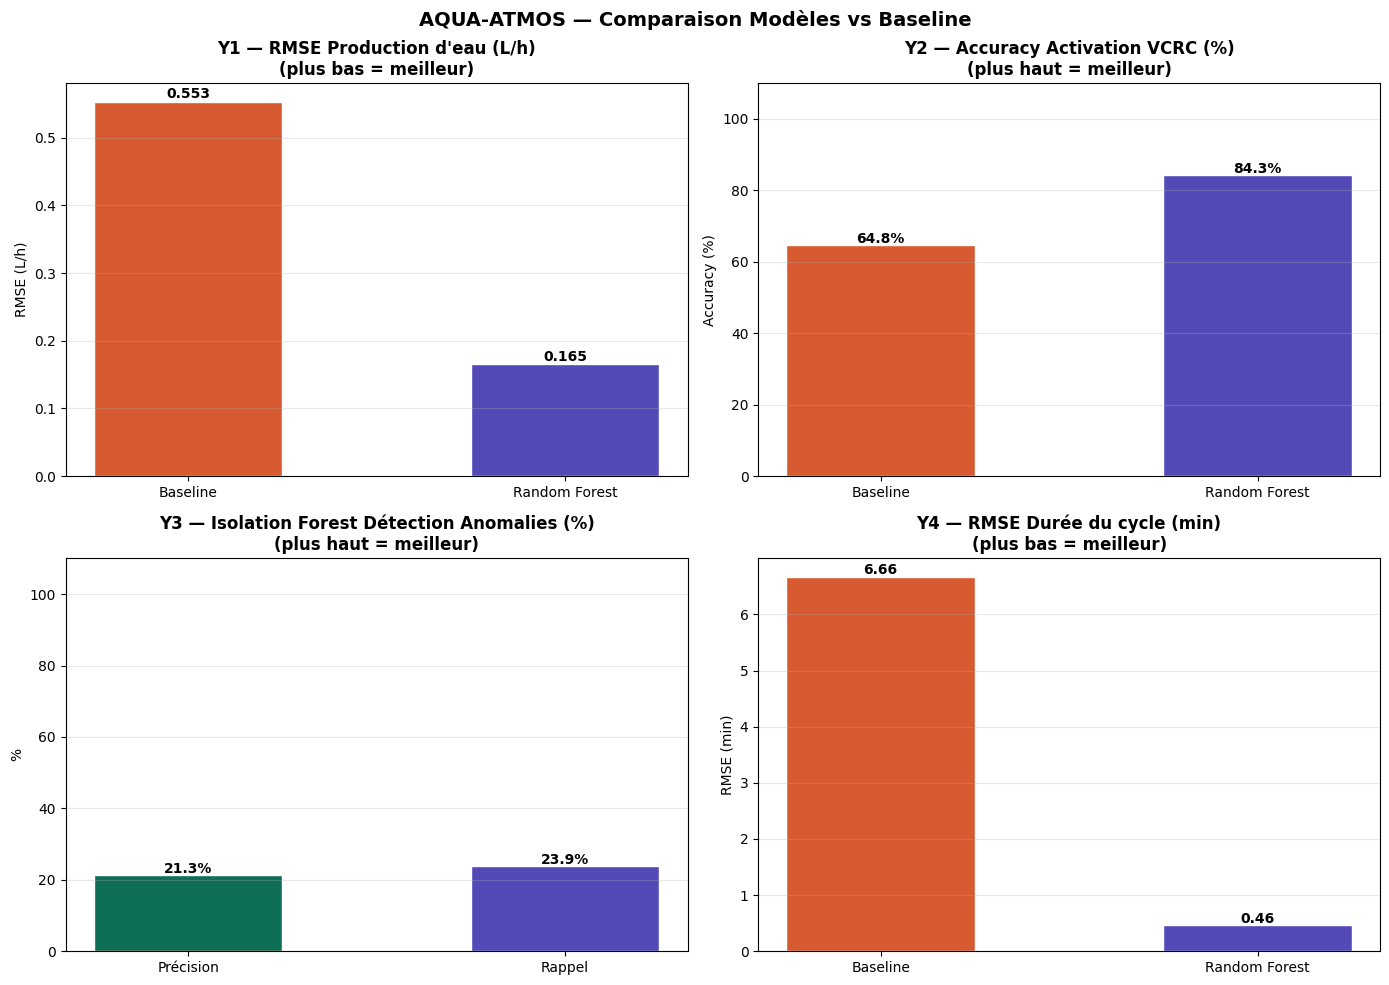

✅ Figure sauvegardée : comparaison_modeles.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AQUA-ATMOS — Comparaison Modèles vs Baseline', fontsize=14, fontweight='bold')

# ── Y1 — RMSE ──
ax = axes[0, 0]
vals = [rmse_baseline, rmse_test]
bars = ax.bar(['Baseline', 'Random Forest'], vals, color=['#D85A30', '#534AB7'], edgecolor='white', width=0.5)
ax.set_title('Y1 — RMSE Production d\'eau (L/h)\n(plus bas = meilleur)', fontweight='bold')
ax.set_ylabel('RMSE (L/h)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# ── Y2 — Accuracy ──
ax = axes[0, 1]
vals = [baseline_acc*100, acc_test*100]
bars = ax.bar(['Baseline', 'Random Forest'], vals, color=['#D85A30', '#534AB7'], edgecolor='white', width=0.5)
ax.set_title('Y2 — Accuracy Activation VCRC (%)\n(plus haut = meilleur)', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# ── Y3 — Précision détection anomalies ──
ax = axes[1, 0]
report = classification_report(Y3_test, Y3_pred_test, output_dict=True)
precision = report['1']['precision'] * 100
recall    = report['1']['recall'] * 100
vals = [precision, recall]
bars = ax.bar(['Précision', 'Rappel'], vals, color=['#0F6E56', '#534AB7'], edgecolor='white', width=0.5)
ax.set_title('Y3 — Isolation Forest Détection Anomalies (%)\n(plus haut = meilleur)', fontweight='bold')
ax.set_ylabel('%')
ax.set_ylim(0, 110)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# ── Y4 — RMSE ──
ax = axes[1, 1]
vals = [rmse_base_y4, rmse_y4]
bars = ax.bar(['Baseline', 'Random Forest'], vals, color=['#D85A30', '#534AB7'], edgecolor='white', width=0.5)
ax.set_title('Y4 — RMSE Durée du cycle (min)\n(plus bas = meilleur)', fontweight='bold')
ax.set_ylabel('RMSE (min)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : comparaison_modeles.png")

In [ ]:
print("=" * 60)
print("TABLEAU RÉCAPITULATIF — RÉSULTATS FINAUX")
print("=" * 60)

resultats = pd.DataFrame({
    'Sortie': ['Y1 — Production (L/h)', 'Y2 — Activation VCRC', 'Y3 — Anomalies', 'Y4 — Durée cycle (min)'],
    'Modèle': ['Random Forest', 'Random Forest', 'Isolation Forest', 'Random Forest'],
    'Métrique': ['RMSE', 'Accuracy', 'Précision / Rappel', 'RMSE'],
    'Baseline': [f'{rmse_baseline:.3f}', f'{baseline_acc*100:.1f}%', '—', f'{rmse_base_y4:.2f}'],
    'Modèle IA': [f'{rmse_test:.3f}', f'{acc_test*100:.1f}%', f'{precision:.1f}% / {recall:.1f}%', f'{rmse_y4:.2f}'],
    'Amélioration': [
        f'{((rmse_baseline - rmse_test)/rmse_baseline)*100:.1f}%',
        f'{((acc_test - baseline_acc)/baseline_acc)*100:.1f}%',
        '—',
        f'{((rmse_base_y4 - rmse_y4)/rmse_base_y4)*100:.1f}%'
    ]
})

display(resultats)
print("\n✅ Entraînement complet terminé — résultats prêts pour la soutenance")

TABLEAU RÉCAPITULATIF — RÉSULTATS FINAUX


,Sortie,Modèle,Métrique,Baseline,Modèle IA,Amélioration
0,Y1 — Production (L/h),Random Forest,RMSE,0.553,0.165,70.1%
1,Y2 — Activation VCRC,Random Forest,Accuracy,64.8%,84.3%,30.1%
2,Y3 — Anomalies,Isolation Forest,Précision / Rappel,—,21.3% / 23.9%,—
3,Y4 — Durée cycle (min),Random Forest,RMSE,6.66,0.46,93.1%



✅ Entraînement complet terminé — résultats prêts pour la soutenance


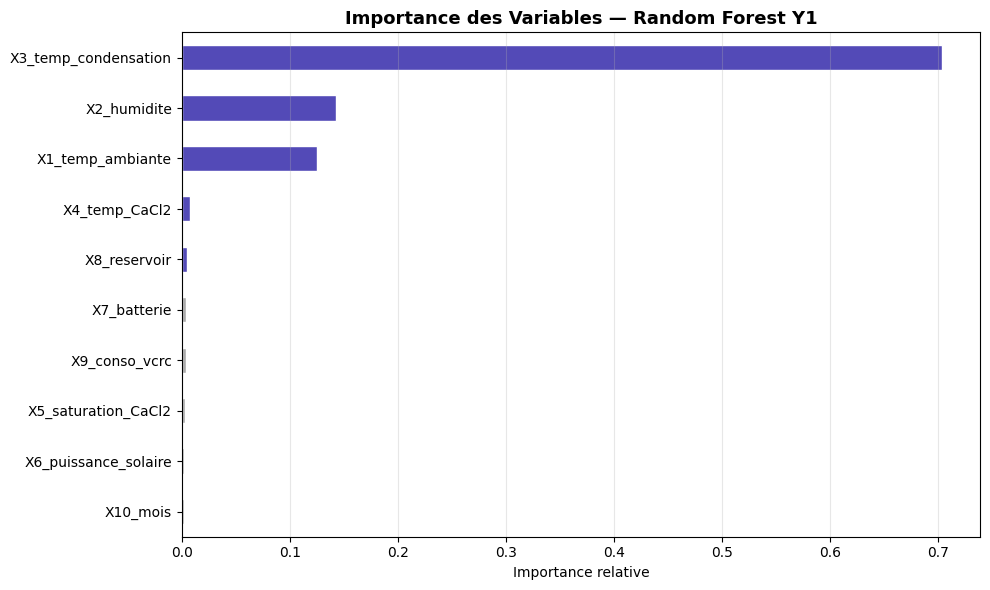

✅ Figure sauvegardée : importance_variables.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

importances = pd.Series(rf_y1.feature_importances_, index=X.columns).sort_values()
colors = ['#534AB7' if v > importances.median() else '#AAAAAA' for v in importances]

importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("Importance des Variables — Random Forest Y1", fontweight='bold', fontsize=13)
ax.set_xlabel("Importance relative")
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importance_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : importance_variables.png")

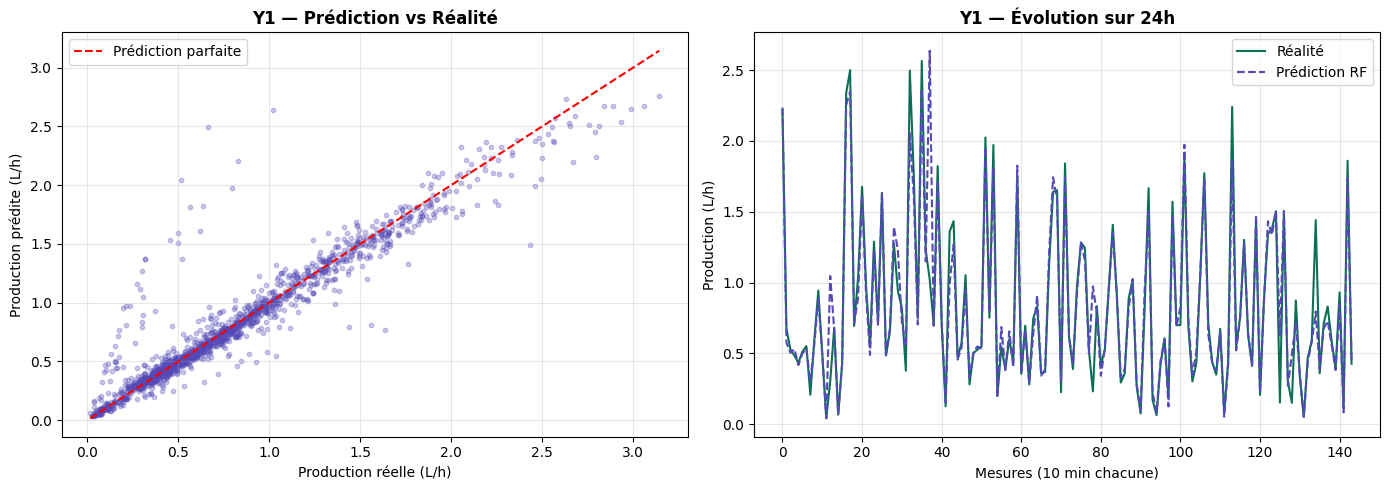

✅ Figure sauvegardée : prediction_vs_realite.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot — prédit vs réel
ax = axes[0]
ax.scatter(Y1_test, Y1_pred_test, alpha=0.3, color='#534AB7', s=10)
ax.plot([Y1_test.min(), Y1_test.max()],
        [Y1_test.min(), Y1_test.max()],
        'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Production réelle (L/h)')
ax.set_ylabel('Production prédite (L/h)')
ax.set_title('Y1 — Prédiction vs Réalité', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Évolution temporelle sur 144 mesures (1 jour)
ax = axes[1]
n = 144
ax.plot(Y1_test.values[:n], color='#0F6E56', linewidth=1.5, label='Réalité')
ax.plot(Y1_pred_test[:n], color='#534AB7', linewidth=1.5, linestyle='--', label='Prédiction RF')
ax.set_xlabel('Mesures (10 min chacune)')
ax.set_ylabel('Production (L/h)')
ax.set_title('Y1 — Évolution sur 24h', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_vs_realite.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : prediction_vs_realite.png")

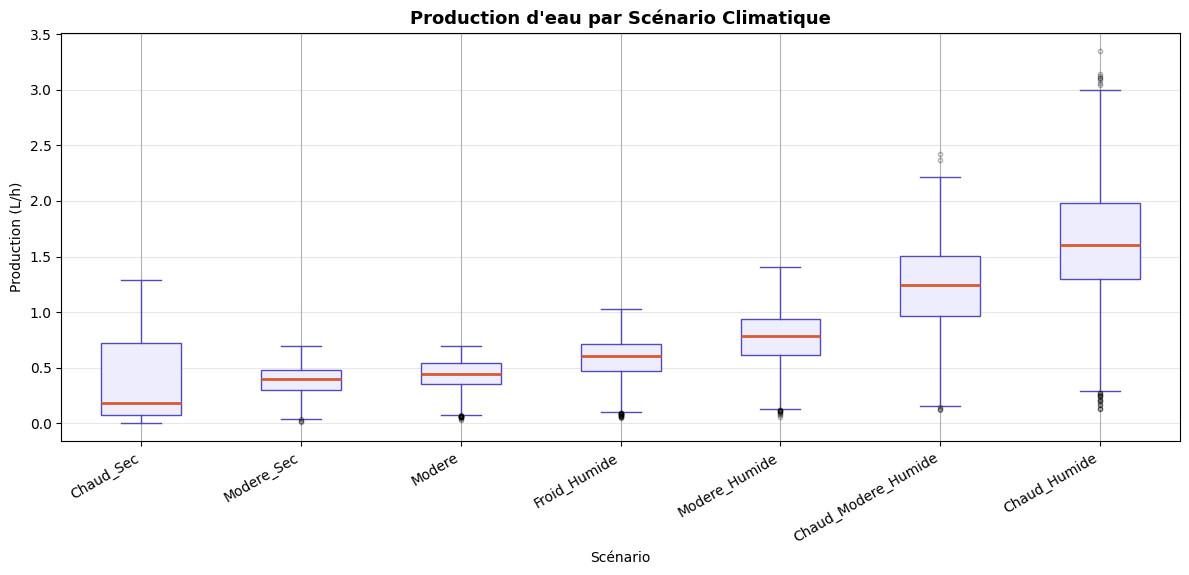

✅ Figure sauvegardée : production_par_scenario.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Trier manuellement par médiane
scenario_order = df.groupby('scenario')['Y1_production'].median().sort_values().index.tolist()
df['scenario'] = pd.Categorical(df['scenario'], categories=scenario_order, ordered=True)
df_sorted = df.sort_values('scenario')

df_sorted.boxplot(column='Y1_production', by='scenario',
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='#EEEDFE', color='#534AB7'),
           medianprops=dict(color='#D85A30', linewidth=2),
           whiskerprops=dict(color='#534AB7'),
           capprops=dict(color='#534AB7'),
           flierprops=dict(marker='o', color='#534AB7', alpha=0.3, markersize=3))

ax.set_title("Production d'eau par Scénario Climatique", fontweight='bold', fontsize=13)
ax.set_xlabel('Scénario')
ax.set_ylabel('Production (L/h)')
plt.suptitle('')
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('production_par_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : production_par_scenario.png")

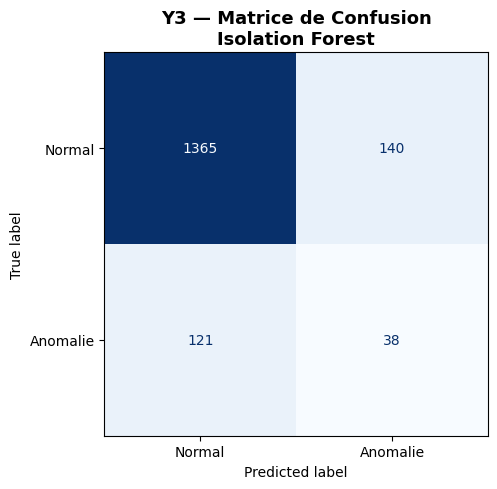

✅ Figure sauvegardée : confusion_matrix_Y3.png


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Anomalie'])
disp.plot(ax=ax, colorbar=False,
          cmap='Blues',
          values_format='d')

ax.set_title('Y3 — Matrice de Confusion\nIsolation Forest', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrix_Y3.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : confusion_matrix_Y3.png")

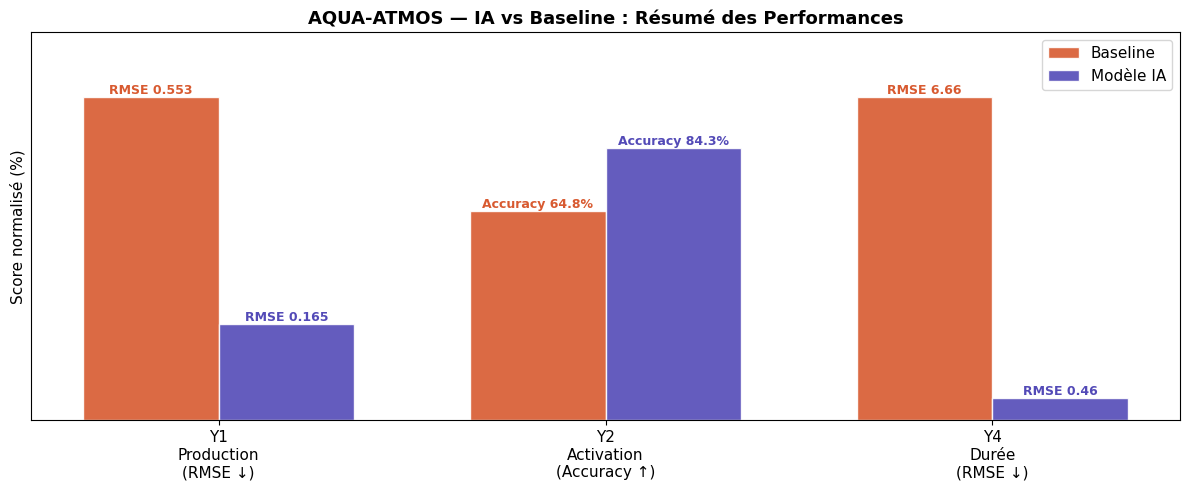

✅ Figure sauvegardée : resume_final.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

categories = ['Y1\nProduction\n(RMSE ↓)', 'Y2\nActivation\n(Accuracy ↑)', 'Y4\nDurée\n(RMSE ↓)']
baseline_vals  = [100, 64.8, 100]
modele_vals    = [100 - 70.1, 84.3, 100 - 93.1]
labels_base    = ['RMSE 0.553', 'Accuracy 64.8%', 'RMSE 6.66']
labels_modele  = ['RMSE 0.165', 'Accuracy 84.3%', 'RMSE 0.46']

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline',
               color='#D85A30', edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, modele_vals, width, label='Modèle IA',
               color='#534AB7', edgecolor='white', alpha=0.9)

for bar, label in zip(bars1, labels_base):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            label, ha='center', fontsize=9, color='#D85A30', fontweight='bold')

for bar, label in zip(bars2, labels_modele):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            label, ha='center', fontsize=9, color='#534AB7', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Score normalisé (%)', fontsize=11)
ax.set_title('AQUA-ATMOS — IA vs Baseline : Résumé des Performances',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 120)
ax.grid(axis='y', alpha=0.3)
ax.set_yticks([])

plt.tight_layout()
plt.savefig('resume_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : resume_final.png")

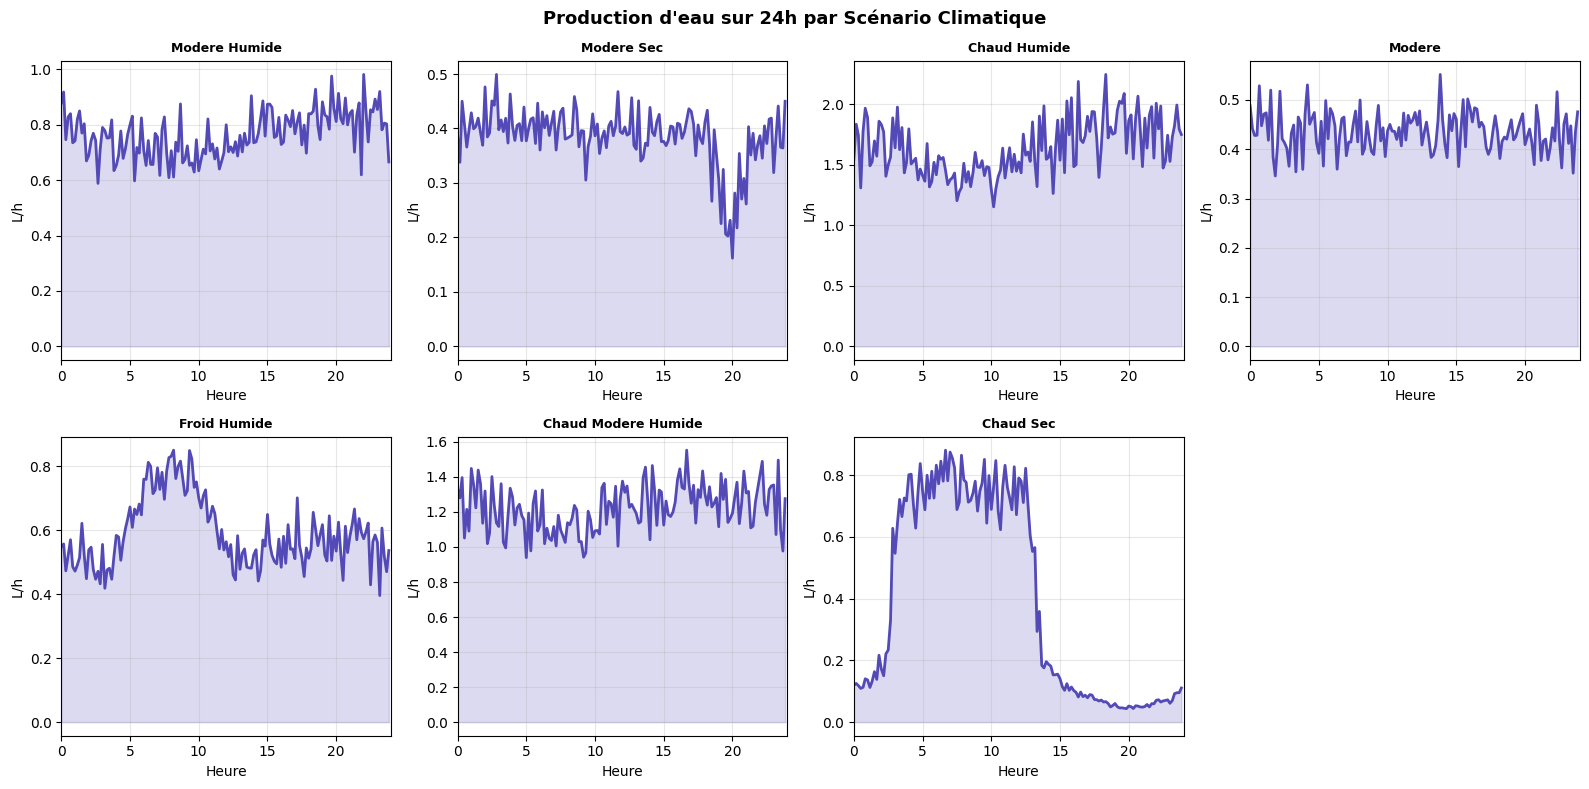

✅ Figure sauvegardée : production_24h_scenarios.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Production d'eau sur 24h par Scénario Climatique", fontweight='bold', fontsize=13)

scenarios = df['scenario'].unique()
axes_flat = axes.flatten()

for i, sc in enumerate(scenarios):
    ax = axes_flat[i]
    sc_data = df[df['scenario'] == sc].groupby('heure')['Y1_production'].mean()
    ax.plot(sc_data.index, sc_data.values, color='#534AB7', linewidth=2)
    ax.fill_between(sc_data.index, sc_data.values, alpha=0.2, color='#534AB7')
    ax.set_title(sc.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Heure')
    ax.set_ylabel('L/h')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 24)

# Cacher le dernier subplot vide
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('production_24h_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : production_24h_scenarios.png")

/tmp/ipykernel_10882/3175039966.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activation_par_sc = df.groupby('scenario')['Y2_activation'].mean() * 100


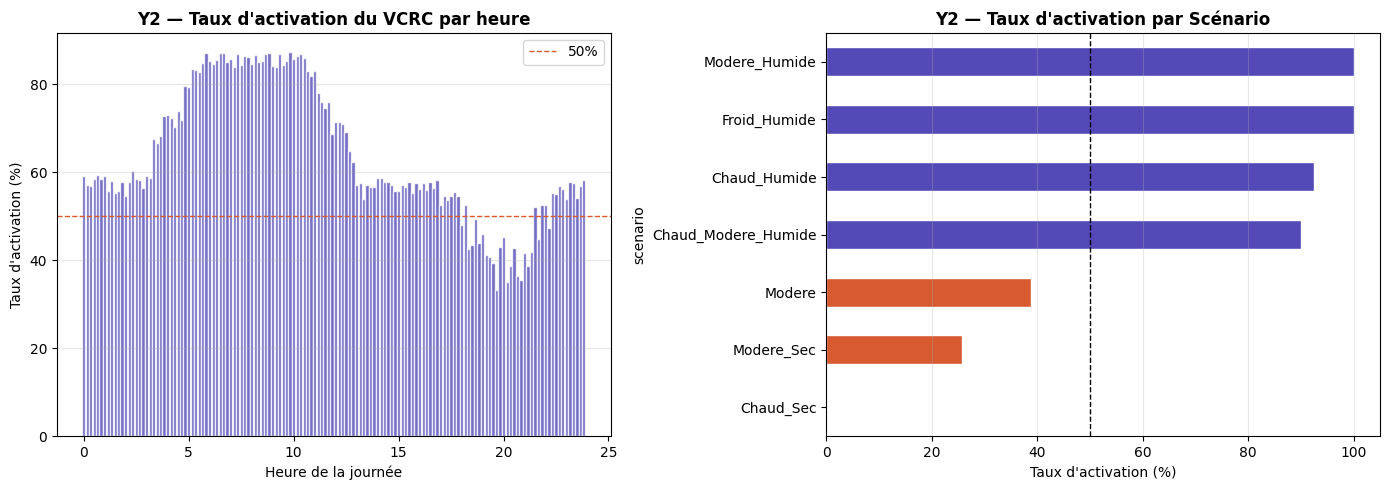

✅ Figure sauvegardée : activation_vcrc.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Activation par heure de la journée
ax = axes[0]
activation_par_heure = df.groupby('heure')['Y2_activation'].mean() * 100
ax.bar(activation_par_heure.index, activation_par_heure.values,
       color='#534AB7', alpha=0.8, edgecolor='white', width=0.15)
ax.set_title("Y2 — Taux d'activation du VCRC par heure", fontweight='bold')
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Taux d'activation (%)")
ax.axhline(50, color='#D85A30', linestyle='--', linewidth=1, label='50%')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Activation par scénario
ax = axes[1]
activation_par_sc = df.groupby('scenario')['Y2_activation'].mean() * 100
activation_par_sc = activation_par_sc.sort_values()
colors = ['#D85A30' if v < 50 else '#534AB7' for v in activation_par_sc]
activation_par_sc.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("Y2 — Taux d'activation par Scénario", fontweight='bold')
ax.set_xlabel("Taux d'activation (%)")
ax.axvline(50, color='black', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('activation_vcrc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : activation_vcrc.png")

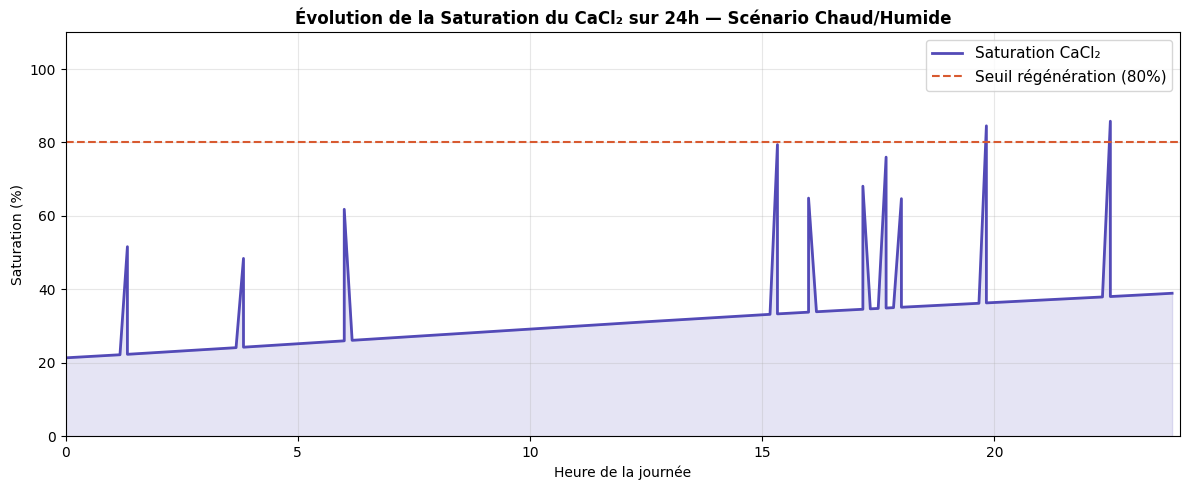

✅ Figure sauvegardée : saturation_CaCl2.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

# Prendre un jour d'un scénario humide
sample = df[(df['scenario'] == 'Chaud_Humide') & (df['jour'] == 1)].sort_values('heure')

ax.plot(sample['heure'], sample['X5_saturation_CaCl2'],
        color='#534AB7', linewidth=2, label='Saturation CaCl₂')
ax.axhline(80, color='#D85A30', linestyle='--', linewidth=1.5, label='Seuil régénération (80%)')
ax.fill_between(sample['heure'], sample['X5_saturation_CaCl2'],
                alpha=0.15, color='#534AB7')

ax.set_title("Évolution de la Saturation du CaCl₂ sur 24h — Scénario Chaud/Humide",
             fontweight='bold', fontsize=12)
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Saturation (%)")
ax.set_xlim(0, 24)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('saturation_CaCl2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : saturation_CaCl2.png")

/tmp/ipykernel_10882/3862724043.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lwh_par_sc = df_active.groupby('scenario')['LWh'].mean().sort_values()


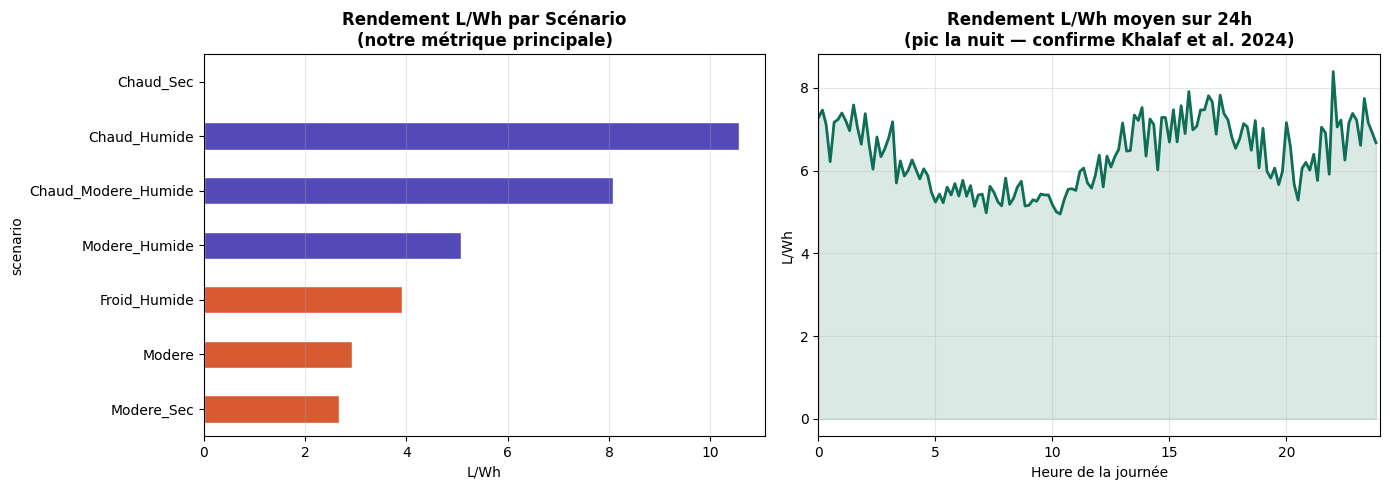

✅ Figure sauvegardée : rendement_LWh.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L/Wh par scénario
ax = axes[0]
df_active = df[df['Y2_activation'] == 1].copy()
df_active['LWh'] = df_active['Y1_production'] / (df_active['X9_conso_vcrc'] / 1000)
lwh_par_sc = df_active.groupby('scenario')['LWh'].mean().sort_values()
colors = ['#D85A30' if v < lwh_par_sc.median() else '#534AB7' for v in lwh_par_sc]
lwh_par_sc.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title("Rendement L/Wh par Scénario\n(notre métrique principale)", fontweight='bold')
ax.set_xlabel("L/Wh")
ax.grid(axis='x', alpha=0.3)

# Évolution L/Wh sur 24h
ax = axes[1]
lwh_par_heure = df_active.groupby('heure')['LWh'].mean()
ax.plot(lwh_par_heure.index, lwh_par_heure.values,
        color='#0F6E56', linewidth=2)
ax.fill_between(lwh_par_heure.index, lwh_par_heure.values,
                alpha=0.15, color='#0F6E56')
ax.set_title("Rendement L/Wh moyen sur 24h\n(pic la nuit — confirme Khalaf et al. 2024)",
             fontweight='bold')
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("L/Wh")
ax.set_xlim(0, 24)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rendement_LWh.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : rendement_LWh.png")

In [ ]:
print(df.head(5).to_string(index=False))

     scenario  jour  heure  X1_temp_ambiante  X2_humidite  X3_temp_condensation  X4_temp_CaCl2  X5_saturation_CaCl2  X6_puissance_solaire  X7_batterie  X8_reservoir  X9_conso_vcrc  X10_mois  Y1_production  Y2_activation  Y3_anomalie  Y4_duree
Modere_Humide     6  10.17             20.94        92.11                 15.21          15.15                40.07                137.61        67.35         26.45         151.42         6          0.634              1            0      32.2
   Modere_Sec     3   8.00             16.83        58.94                  3.04          14.00                16.61                 75.41        84.56         13.64         132.97         3          0.413              1            0      39.5
Modere_Humide     6   3.83             22.52        78.92                 11.45          20.49                35.63                  0.00        73.52         21.60         147.65         6          0.912              1            0      27.0
 Chaud_Humide     3   5.00  